# |<center>**<u>Machine Learning for Finance</u>**</center>

<figure style="text-align: center;">
    <img src="notebook_images/ml_finance/ml_finance01.png", alt="Finance">
</figure>


## GPU ACCELERATION

In [1]:
%load_ext cudf.pandas
%load_ext cuml.accel

---

## IMPORTS

In [25]:
import pandas as pd
import cudf
import numpy as np
import cupy as cp


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(rc={'figure.figsize':(12, 8)})

import talib




---

## DATA LOADING AND PREPARATION

In [6]:
appl_df =pd.read_csv("~/000_Duckspace/Learning/DataScience/Python_DataScience_Examples/data/ml_finance/AAPL.csv")
amd_df = pd.read_csv("~/000_Duckspace/Learning/DataScience/Python_DataScience_Examples/data/ml_finance/AMD.csv")
lng_df = pd.read_csv("~/000_Duckspace/Learning/DataScience/Python_DataScience_Examples/data/ml_finance/LNG.csv")
qqq_df = pd.read_csv("~/000_Duckspace/Learning/DataScience/Python_DataScience_Examples/data/ml_finance/QQQ.csv")
smlv_df = pd.read_csv("~/000_Duckspace/Learning/DataScience/Python_DataScience_Examples/data/ml_finance/SMLV.csv")
spy_df = pd.read_csv("~/000_Duckspace/Learning/DataScience/Python_DataScience_Examples/data/ml_finance/SPY.csv")

---

## SOME EDA TO START

           Date  Adj_Close  Adj_Volume  5d_future_close  5d_close_future_pct  \
200  1995-01-18       25.5         0.0             25.5                  0.0   
201  1995-01-19       25.5         0.0             25.5                  0.0   
202  1995-01-20       25.5         0.0             25.5                  0.0   
203  1995-01-23       25.5         0.0             25.5                  0.0   
204  1995-01-24       25.5         0.0             25.5                  0.0   

     5d_close_pct      ma14      rsi14      ma30     rsi30      ma50  \
200           0.0  1.075630  47.184141  1.000000  53.97374  0.929412   
201           0.0  1.063025  47.184141  1.005882  53.97374  0.932941   
202           0.0  1.050420  47.184141  1.011765  53.97374  0.936471   
203           0.0  1.037815  47.184141  1.017647  53.97374  0.940000   
204           0.0  1.025210  47.184141  1.023529  53.97374  0.943529   

         rsi50     ma200     rsi200  
200  47.529695  1.416471  41.340782  
201  47.52

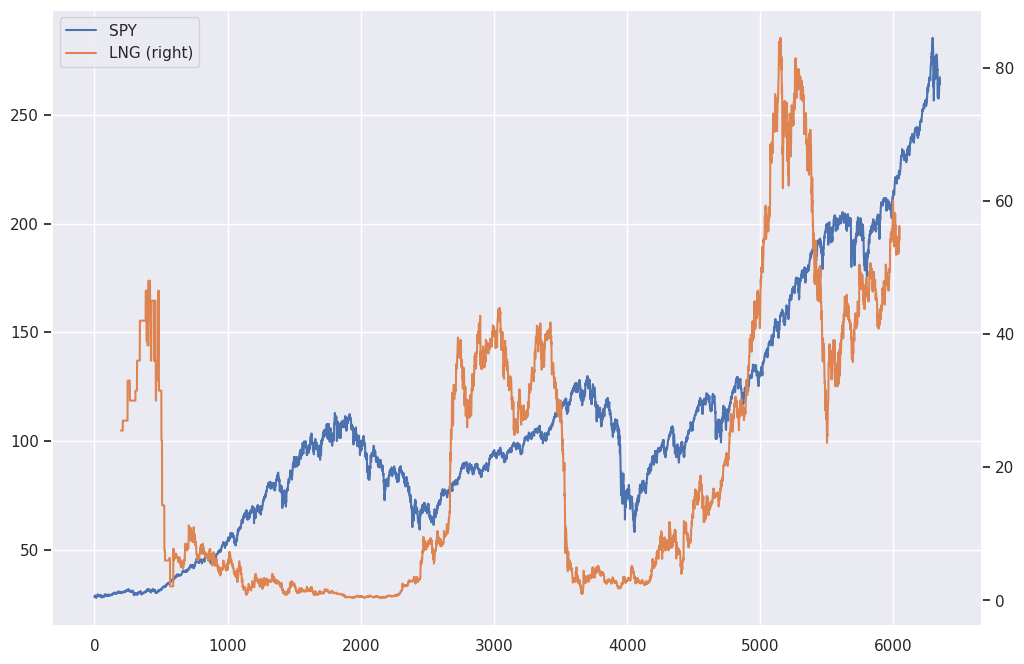

In [26]:
print(lng_df.head())
print(spy_df.head())

spy_df['Adj_Close'].plot(x='Date', label='SPY', legend=True)
lng_df['Adj_Close'].plot(x='Date', label='LNG', legend=True, secondary_y=True)

plt.show()

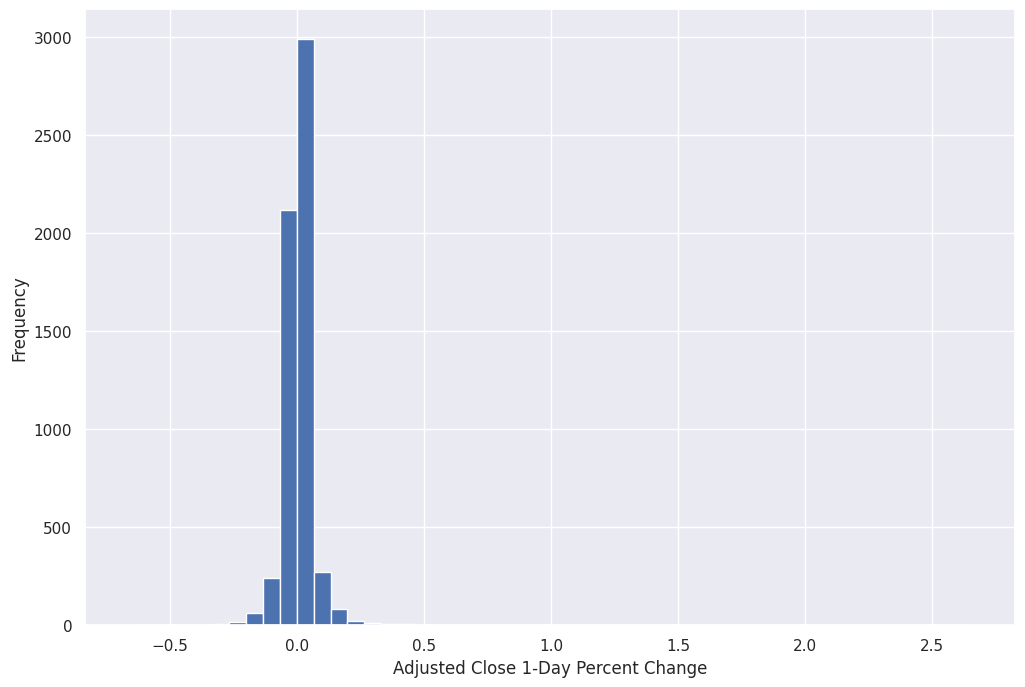

In [27]:
lng_df['Adj_Close'].pct_change().plot.hist(bins=50)
plt.xlabel('Adjusted Close 1-Day Percent Change')
plt.show()

---

## COORELATIONS

                     5d_close_pct  5d_close_future_pct
5d_close_pct             1.000000            -0.002813
5d_close_future_pct     -0.002813             1.000000


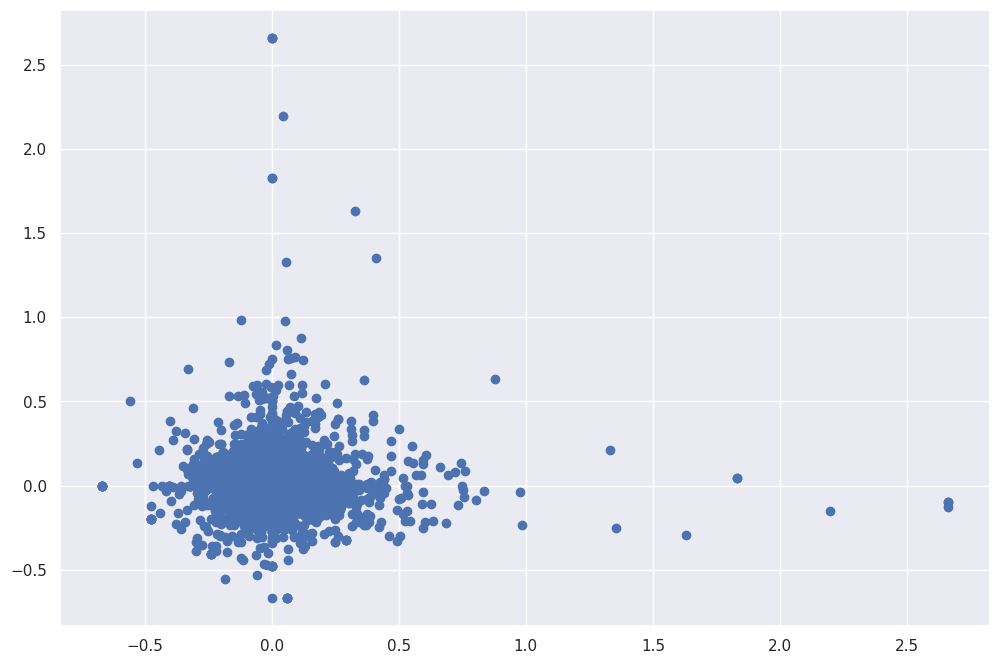

In [28]:
lng_df['5d_future_close'] = lng_df['Adj_Close'].shift(-5)
lng_df['5d_close_future_pct'] = lng_df['5d_future_close'].pct_change(5)
lng_df['5d_close_pct'] = lng_df['Adj_Close'].pct_change(5)

corr = lng_df[['5d_close_pct', '5d_close_future_pct']].corr()
print(corr)

plt.scatter(lng_df['5d_close_pct'], lng_df['5d_close_future_pct'])
plt.show()

---

## DATA TRANSFORMS, FEATURES, AND TARGETS
- $RSI = 100 - \dfrac{100}{1 + RS}$
- $RS = \dfrac{\text{Average Gain over n periods}}{\text{Average Loss over n periods}}$

In [15]:
feature_names = ['5d_close_pct']

for n in [14, 30, 50, 200]:
    lng_df['ma' + str(n)] = talib.SMA(lng_df['Adj_Close'].values, timeperiod=n) / lng_df['Adj_Close']
    lng_df['rsi' + str(n)] = talib.RSI(lng_df['Adj_Close'].values, timeperiod=n)
    feature_names = feature_names + ['ma' + str(n), 'rsi' + str(n)]
print(feature_names)

['5d_close_pct', 'ma14', 'rsi14', 'ma30', 'rsi30', 'ma50', 'rsi50', 'ma200', 'rsi200']


In [31]:
lng_df = lng_df.dropna()

features = lng_df[feature_names]
targets = lng_df['5d_close_future_pct'].values

feature_and_targe_cols = ['5d_close_future_pct'] + feature_names
feat_targ_df = lng_df[feature_and_targe_cols]

corr = feat_targ_df.corr()
corr

,5d_close_future_pct,5d_close_pct,ma14,rsi14,ma30,rsi30,ma50,rsi50,ma200,rsi200
5d_close_future_pct,1.000000,-0.002783,0.005499,-0.023061,0.038737,-0.018060,0.057726,-0.011999,0.142403,0.007153
5d_close_pct,-0.002783,1.000000,-0.719645,0.472481,-0.529660,0.340757,-0.392283,0.261252,-0.137417,0.115588
ma14,0.005499,-0.719645,1.000000,-0.656938,0.866310,-0.549073,0.726902,-0.476251,0.439349,-0.279735
rsi14,-0.023061,0.472481,-0.656938,1.000000,-0.734546,0.940163,-0.694906,0.844802,-0.432508,0.409330
ma30,0.038737,-0.529660,0.866310,-0.734546,1.000000,-0.681690,0.934322,-0.617385,0.602884,-0.382018
rsi30,-0.018060,0.340757,-0.549073,0.940163,-0.681690,1.000000,-0.704742,0.964979,-0.530465,0.518142
ma50,0.057726,-0.392283,0.726902,-0.694906,0.934322,-0.704742,1.000000,-0.666653,0.683038,-0.435349
rsi50,-0.011999,0.261252,-0.476251,0.844802,-0.617385,0.964979,-0.666653,1.000000,-0.591839,0.655683
ma200,0.142403,-0.137417,0.439349,-0.432508,0.602884,-0.530465,0.683038,-0.591839,1.000000,-0.509161
rsi200,0.007153,0.115588,-0.279735,0.409330,-0.382018,0.518142,-0.435349,0.655683,-0.509161,1.000000


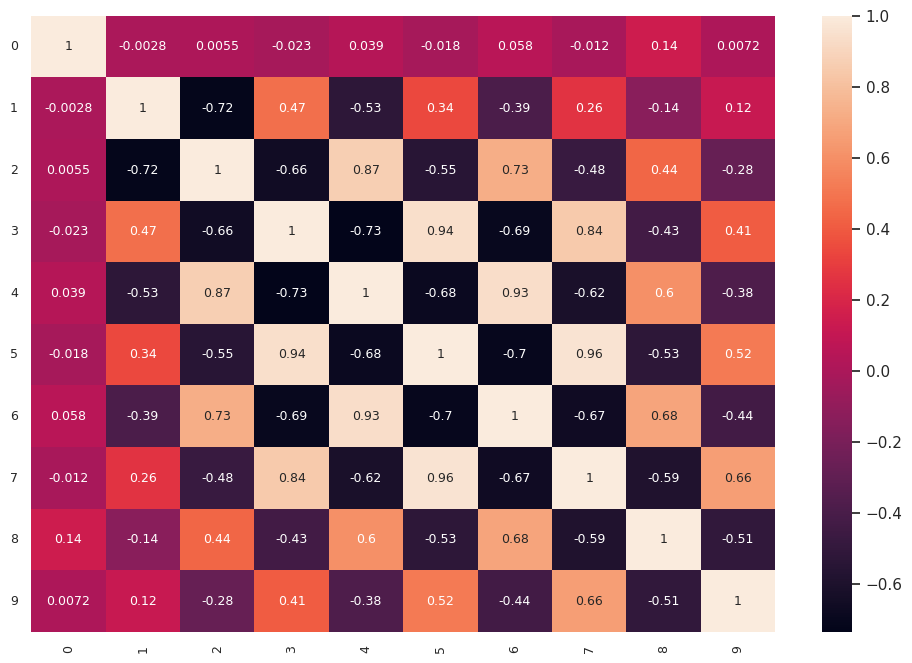

In [32]:
sns.heatmap(corr, annot=True, annot_kws={"size": 9})
plt.yticks(rotation=0, size=9)
plt.xticks(rotation=90, size=9)

plt.show()

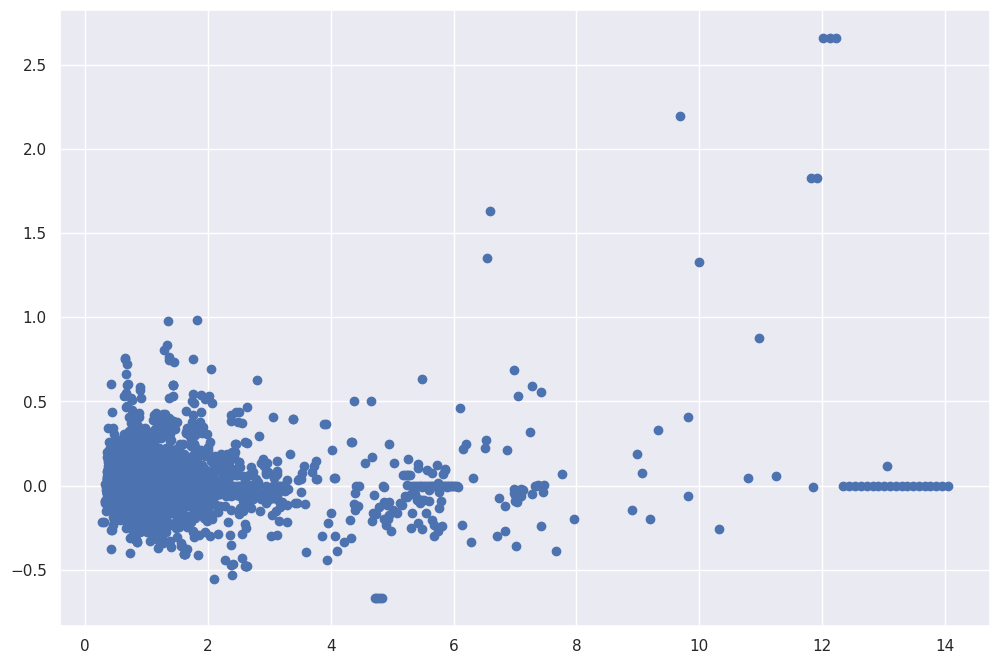

In [33]:
plt.scatter(lng_df['ma200'], lng_df['5d_close_future_pct'])
plt.show()